In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [7]:
data_path = "12_june_data"

# data files are 1.dat 2.dat ... 22.dat
start_file = 1
end_file = 22  

In [8]:
n_samples_per_segment = 512  
overlap_samples = n_samples_per_segment // 2

noise_file_path = os.path.join(data_path, f"{start_file}.dat")
if not os.path.exists(noise_file_path):
    raise FileNotFoundError(f"Baseline noise file '{start_file}.dat' missing.")

### Read baseline noise

In [9]:
def read_noise(noise_file_path):

    with open(noise_file_path, "rb") as f:
        noise_obj = pickle.load(f)

    noise_time = np.array(noise_obj[2][0])
    noise_voltage = np.array(noise_obj[2][1])
    fs_noise = 1.0 / (noise_time[1] - noise_time[0])

    frequencies_noise, noise_psd = signal.welch(
        noise_voltage, fs=fs_noise, nperseg=n_samples_per_segment, noverlap=overlap_samples
    )
    
    fig_noise, (ax_noise_time, ax_noise_psd) = plt.subplots(
    1, 2, figsize=(14, 5), num="Baseline Electrical Noise (1.dat)"
    )

    # Time Domain Subplot (Noise)
    ax_noise_time.plot(noise_time * 1000, noise_voltage, color='purple', linewidth=0.5)
    ax_noise_time.set_xlabel("Time (ms)")
    ax_noise_time.set_ylabel("Voltage (V)")
    ax_noise_time.set_title("Time Domain: 1.dat (Noise Floor)")
    ax_noise_time.grid(True, color='#222222', linestyle='--')

    # PSD Subplot (Noise)
    ax_noise_psd.semilogy(frequencies_noise / 1e3, noise_psd, color='#00bfff', linewidth=1)
    ax_noise_psd.set_xlabel("Frequency (kHz)")
    ax_noise_psd.set_ylabel("PSD ($V^2 / Hz$)")
    ax_noise_psd.set_title("Raw PSD: 1.dat (Noise Floor)")
    ax_noise_psd.grid(True, which='both', color='#222222', linestyle='--')
    fig_noise.tight_layout()

    return noise_time, noise_voltage, frequencies_noise, noise_psd

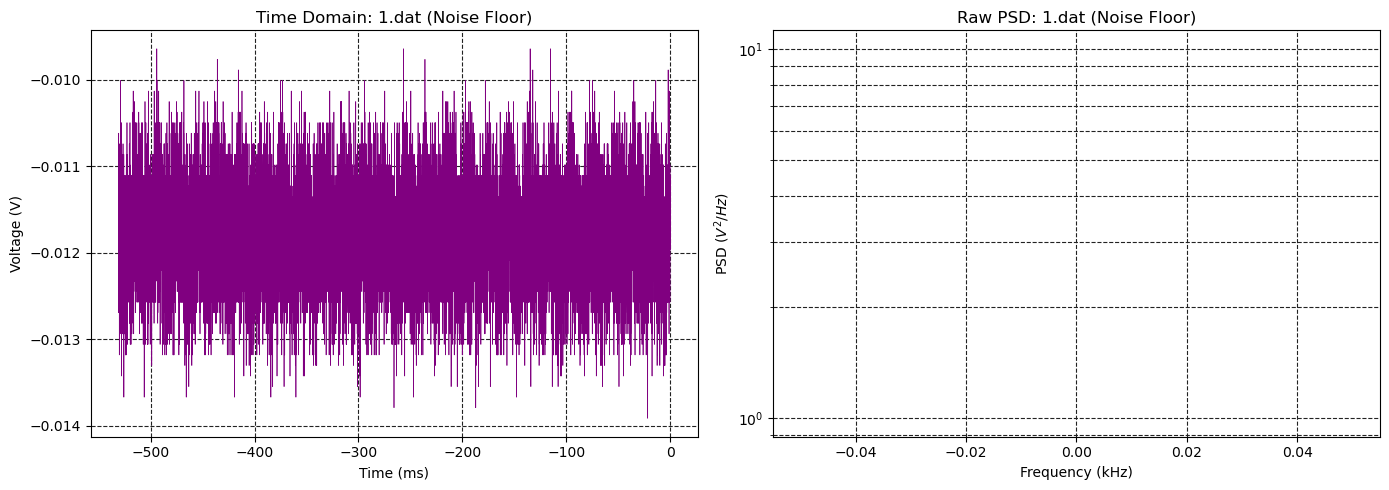

In [10]:
noise_time, noise_voltage, frequencies_noise, noise_psd = read_noise(noise_file_path)

### Plot settings

In [6]:
fig_all_psd = plt.figure(num="Consolidated Raw PSDs", figsize=(11, 6))
fig_avg_clearance = plt.figure(num="Average Clearance Levels", figsize=(11, 6))

colors = plt.cm.plasma(np.linspace(0.3, 0.9, end_file - start_file))
color_idx = 0

file_indices = []
mean_clearances = []

even_idxs = list(range(2, end_file+1, 2))
odd_idxs = list(range(3, end_file+1, 2))

<Figure size 1100x600 with 0 Axes>

<Figure size 1100x600 with 0 Axes>

### Run analysis for each .dat file

In [7]:
def plot_file_data(mean_val, file_name, frequencies, current_psd, time_data, voltage_data):
    
    fig_single, (ax_time, ax_psd_single) = plt.subplots(
        1, 2, figsize=(14, 5), num=f"Acquisition Breakdown: {file_name}"
    )
    
    # Time Domain Subplot
    ax_time.plot(time_data * 1000, voltage_data, color='#00ff00', linewidth=0.5)
    ax_time.set_xlabel("Time (ms)")
    ax_time.set_ylabel("Voltage (V)")
    ax_time.set_title(f"Time Domain: {file_name}")
    ax_time.grid(True, color='#222222', linestyle='--')
    
    # PSD Subplot
    ax_psd_single.semilogy(frequencies / 1e3, current_psd, color='#00bfff', linewidth=1)
    ax_psd_single.set_xlabel("Frequency (kHz)")
    ax_psd_single.set_ylabel("PSD ($V^2 / Hz$)")
    ax_psd_single.set_title(f"Raw PSD: {file_name}")
    ax_psd_single.grid(True, which='both', color='#222222', linestyle='--')
    fig_single.tight_layout()
    
    # IMAGE 2 PATTERN: Consolidated Raw PSD Layout
    plt.figure(fig_all_psd.number)
    plt.semilogy(frequencies / 1e3, current_psd, alpha=0.7, linewidth=1, label=file_name)

    # IMAGE 3 PATTERN: Average Clearance Flat Step Layout
    plt.figure(fig_avg_clearance.number)
    plt.axhline(
        y=mean_val, 
        color=colors[color_idx], 
        linestyle='-', 
        linewidth=2, 
        label=f"File {file_name} Avg ({mean_val:.2f} dB)"
    )

In [8]:
def calculate_file_data(file_idx, noise_psd):
    
    file_name = f"{file_idx}.dat"
    file_path = os.path.join(data_path, file_name)
    
    if not os.path.exists(file_path):
        raise Exception(f"File {file_name} does not exist")
        
    with open(file_path, "rb") as f:
        obj = pickle.load(f)
    
    time_data = np.array(obj[2][0])
    voltage_data = np.array(obj[2][1])
    fs = 1.0 / (time_data[1] - time_data[0])
    
    # Calculate current file's PSD
    frequencies, current_psd = signal.welch(
        voltage_data, fs=fs, nperseg=n_samples_per_segment, noverlap=overlap_samples
    )
    
    clearance_db = 10 * np.log10(current_psd / noise_psd)
    mean_val = np.mean(clearance_db)
    
    return mean_val, file_name, frequencies, current_psd, time_data, voltage_data, fs

### Analysis for even files

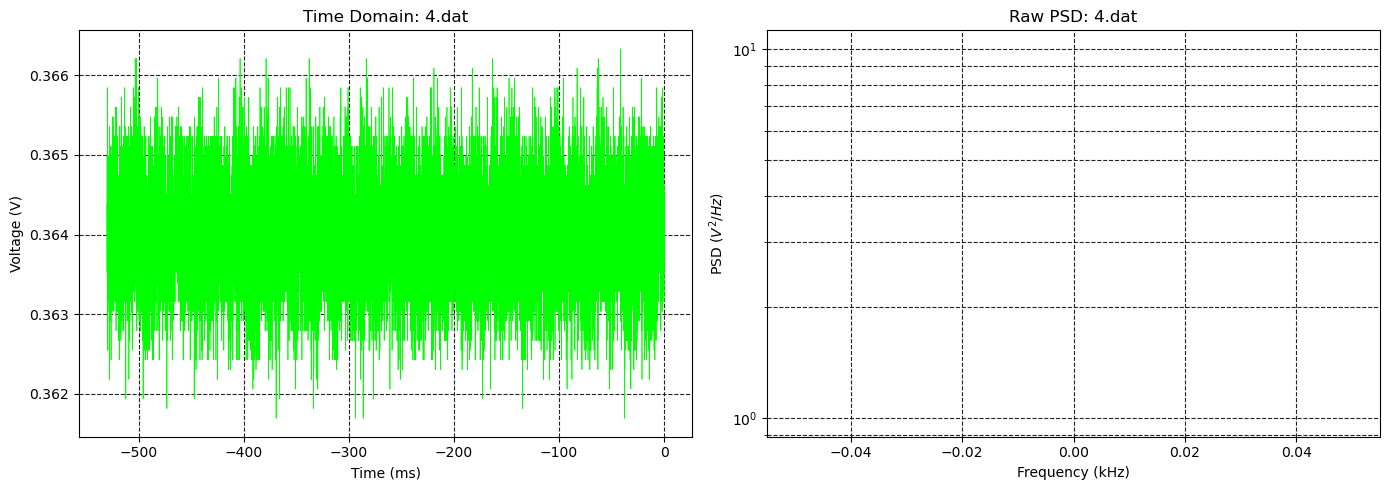

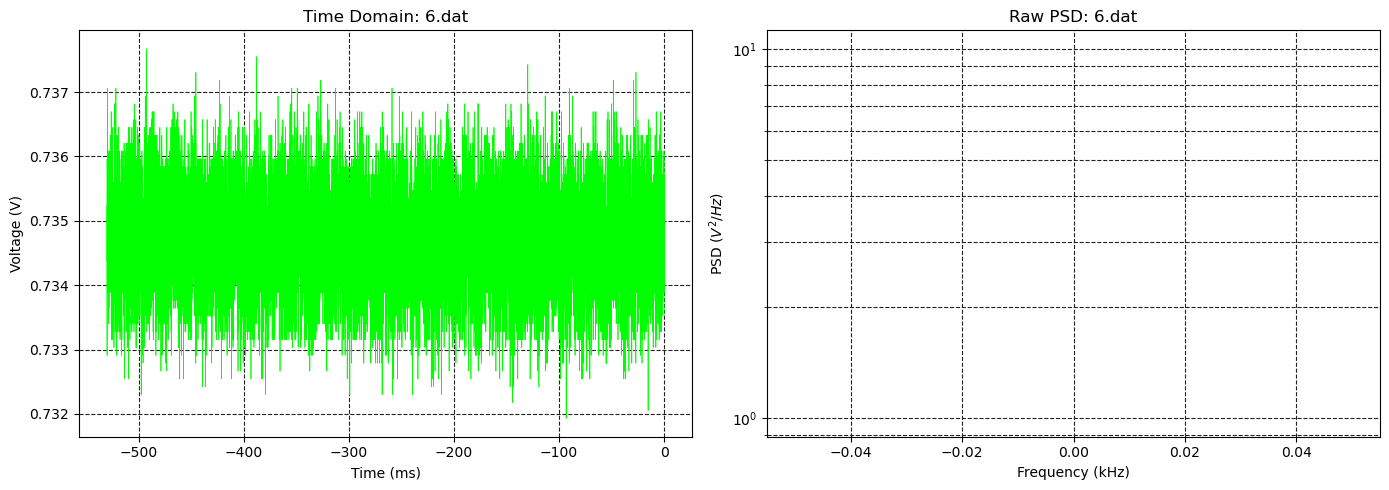

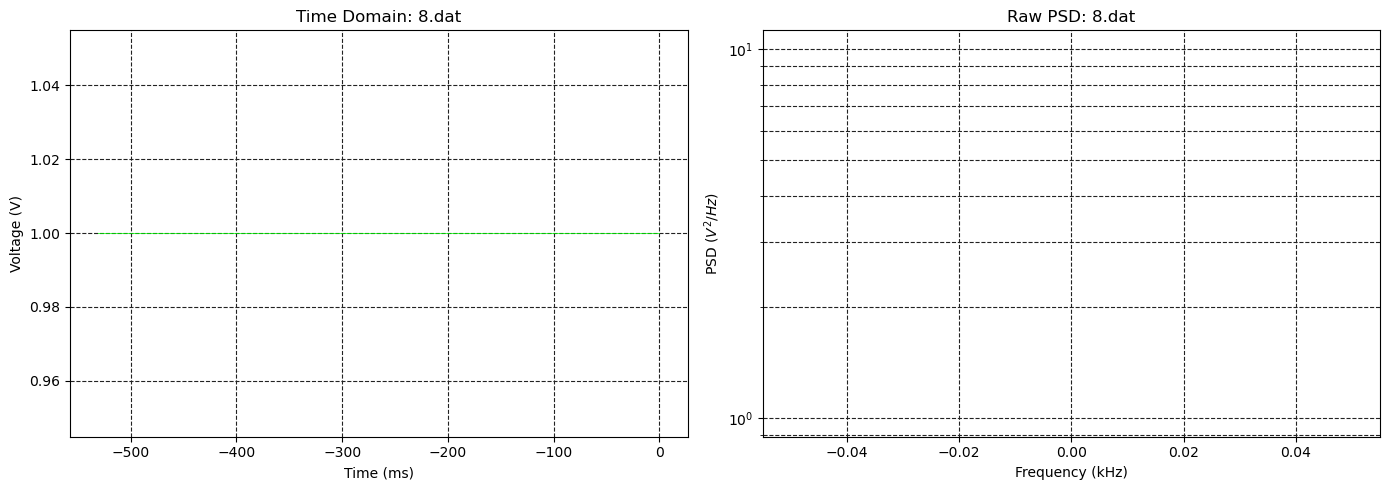

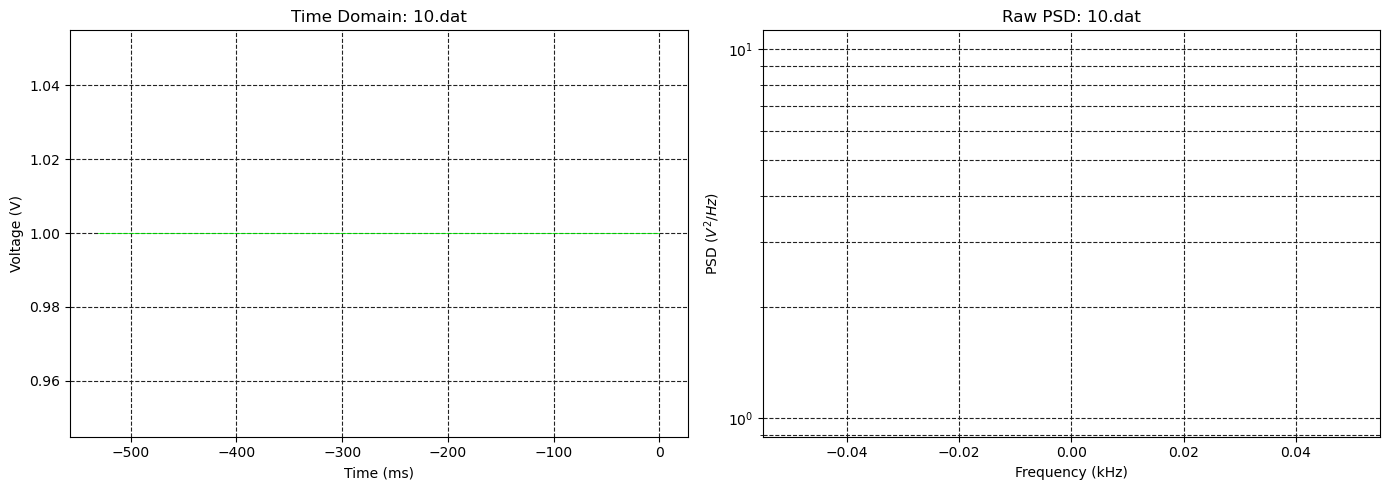

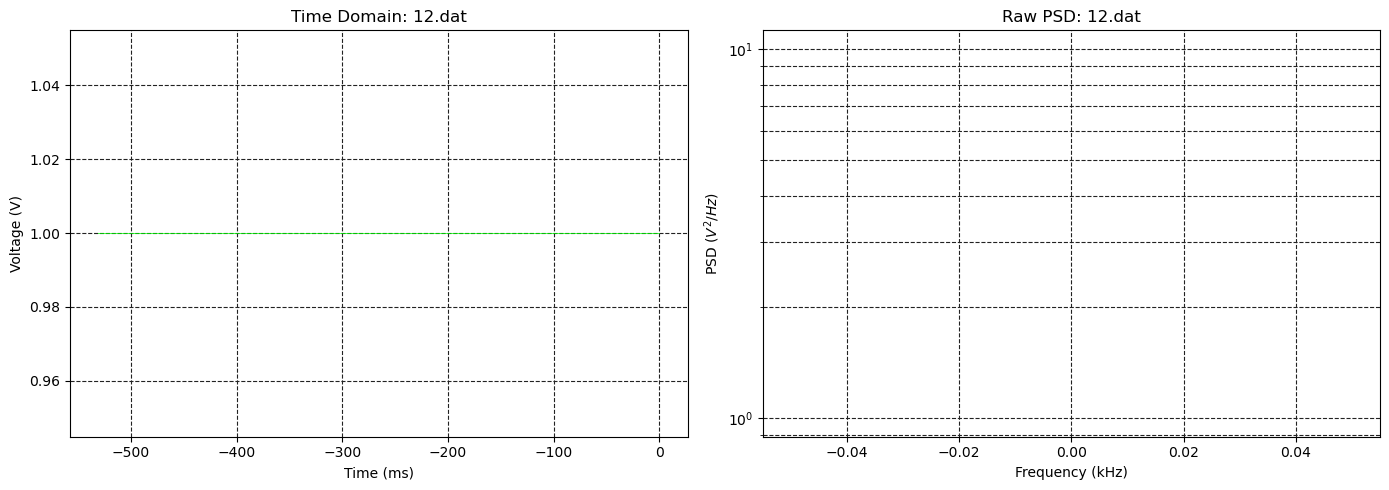

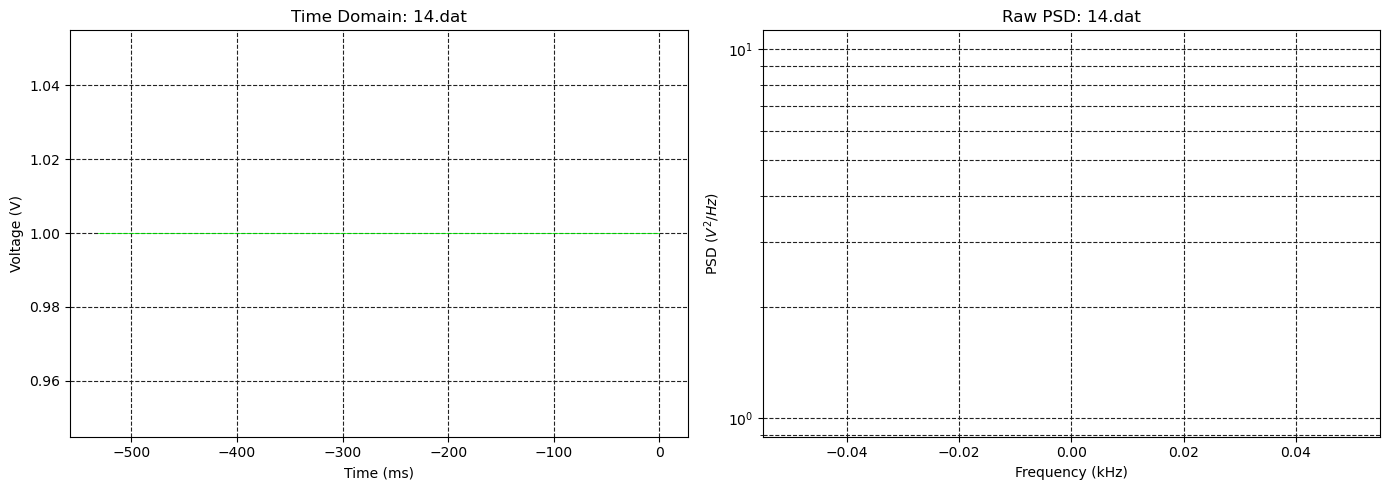

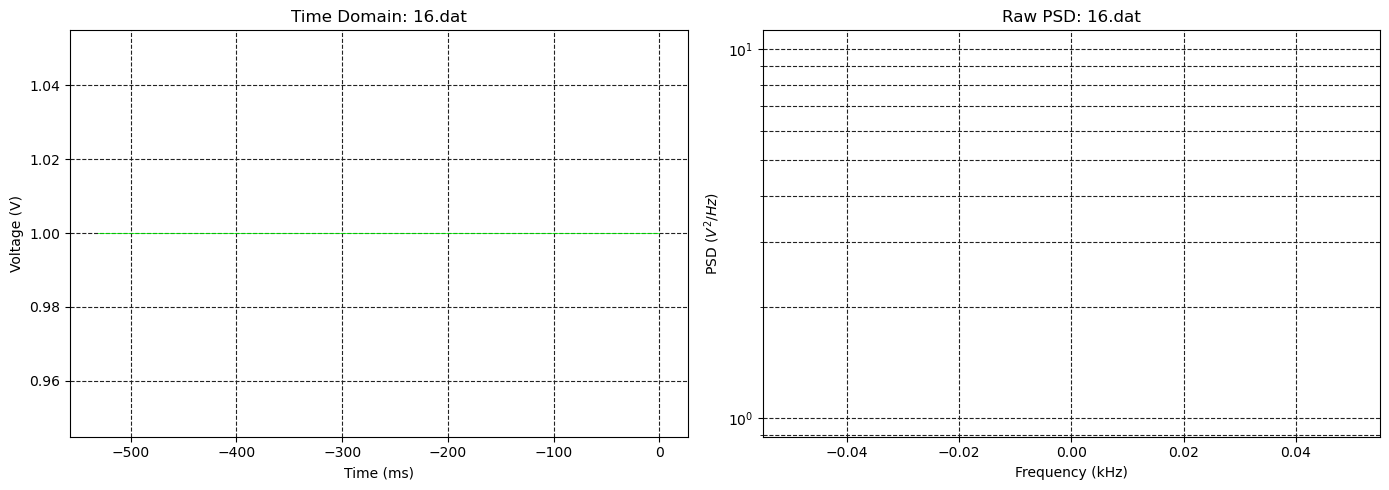

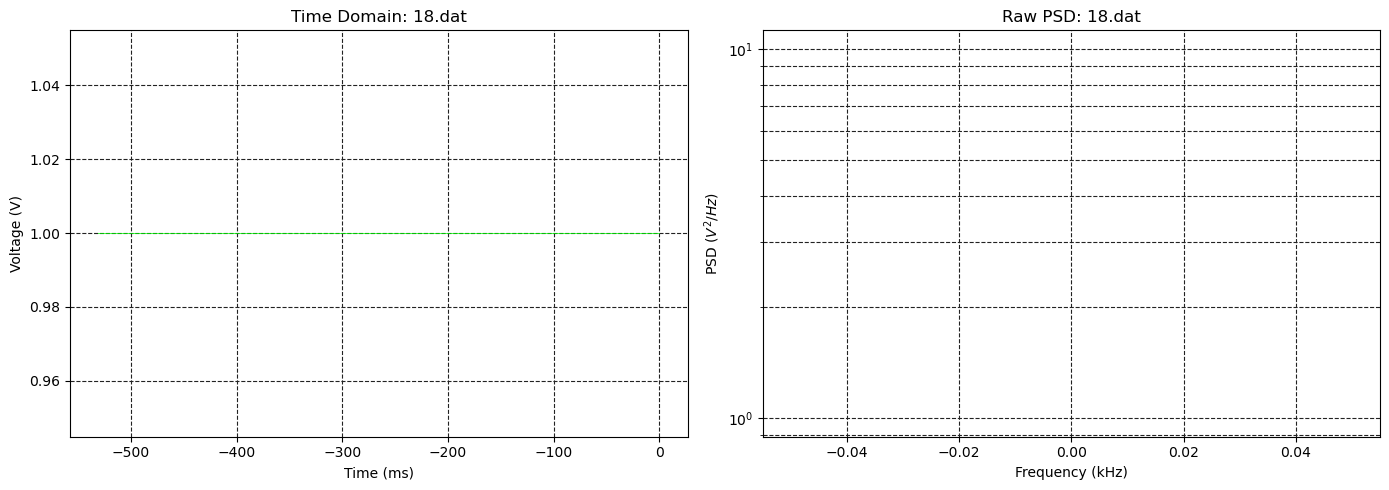

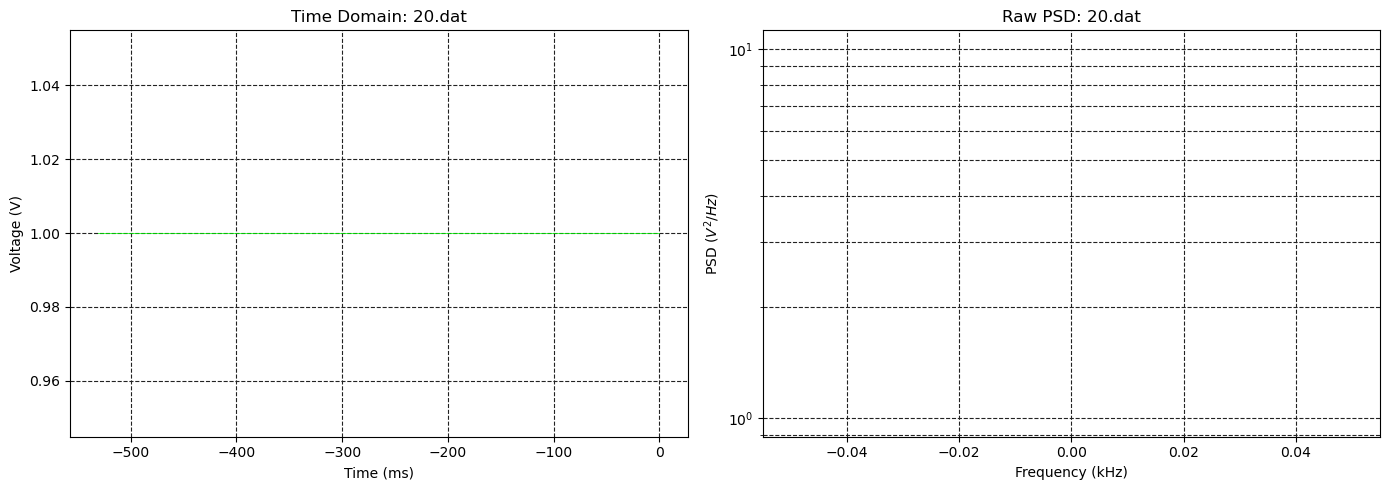

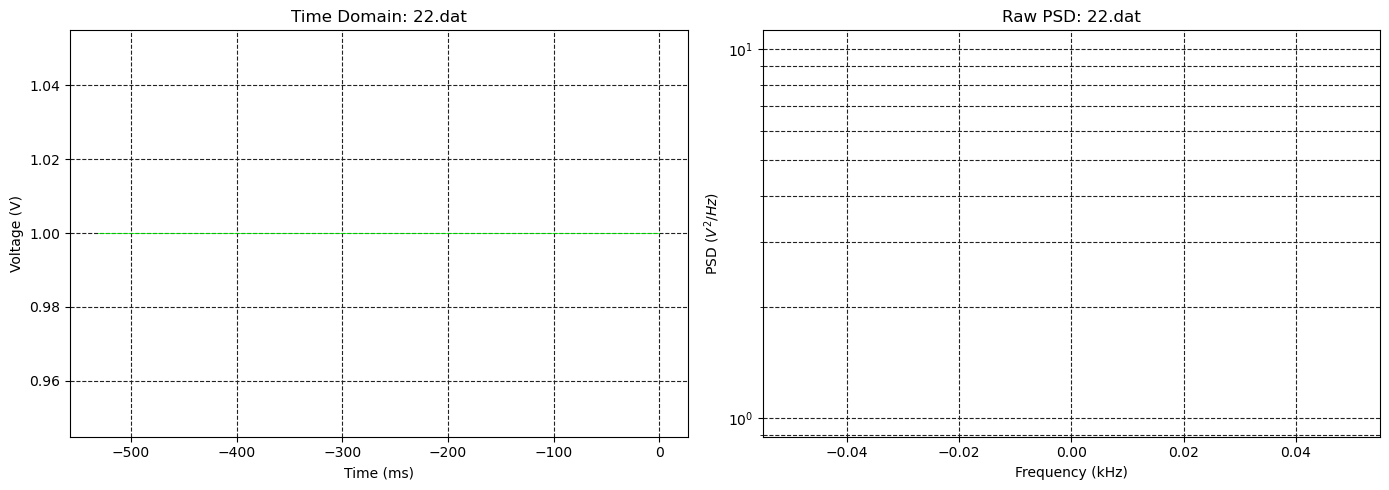

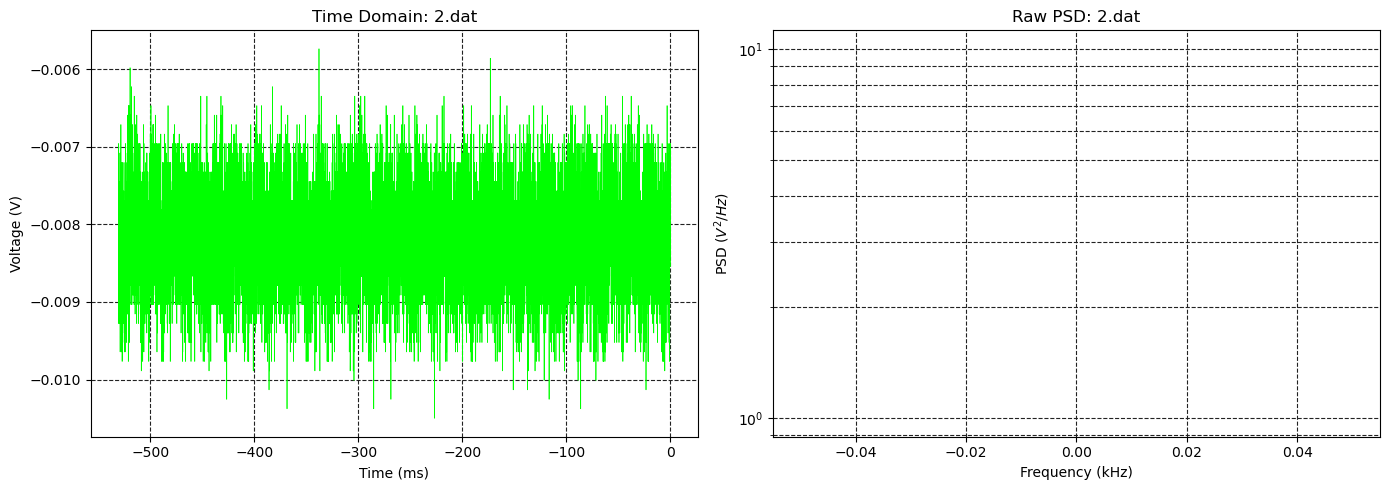

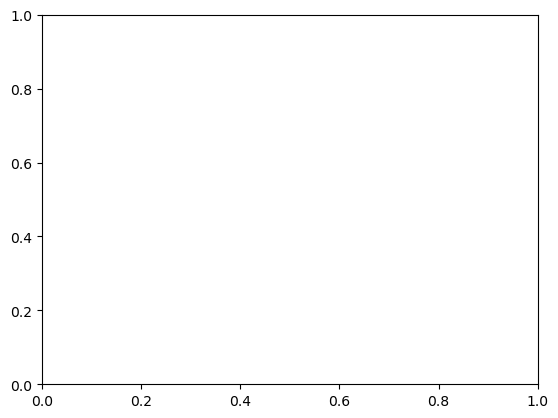

In [9]:
# run analysis for even files
for file_idx in even_idxs:
    mean_val, file_name, frequencies, current_psd, time_data, voltage_data, fs = calculate_file_data(file_idx, noise_psd)

    plot_file_data(mean_val, file_name, frequencies, current_psd, time_data, voltage_data)

    mean_clearances.append(mean_val)
    file_indices.append(file_name)

    color_idx += 1

### Analysis for odd files

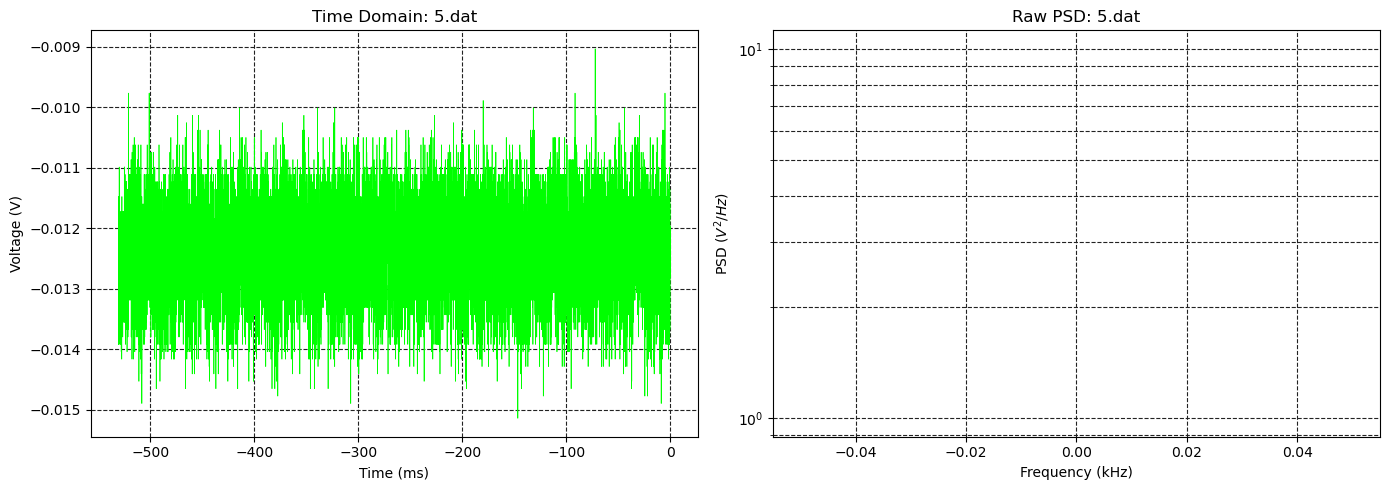

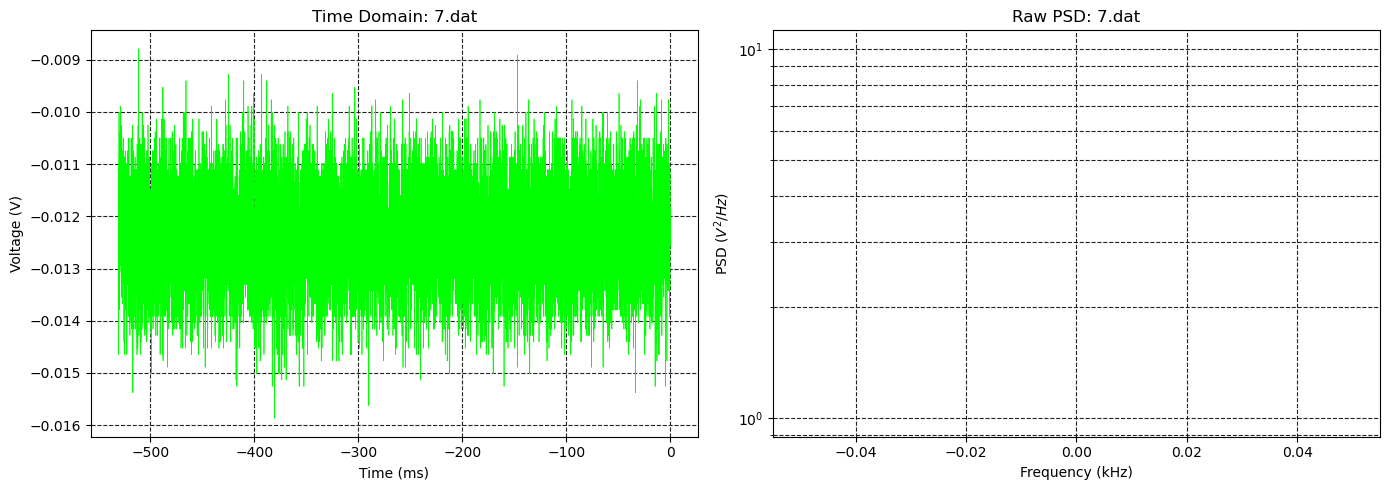

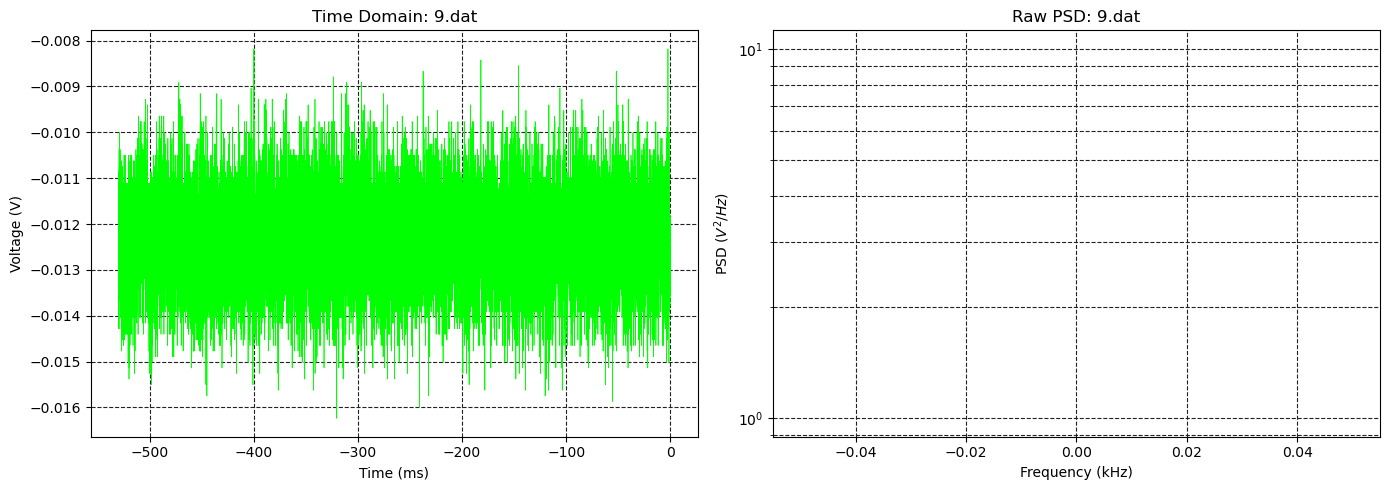

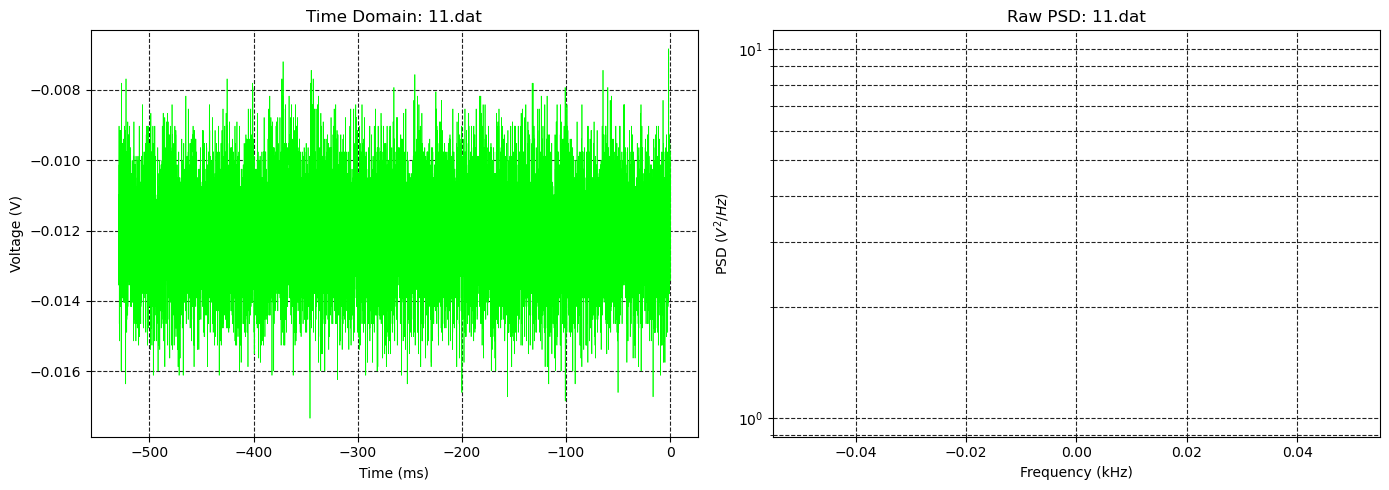

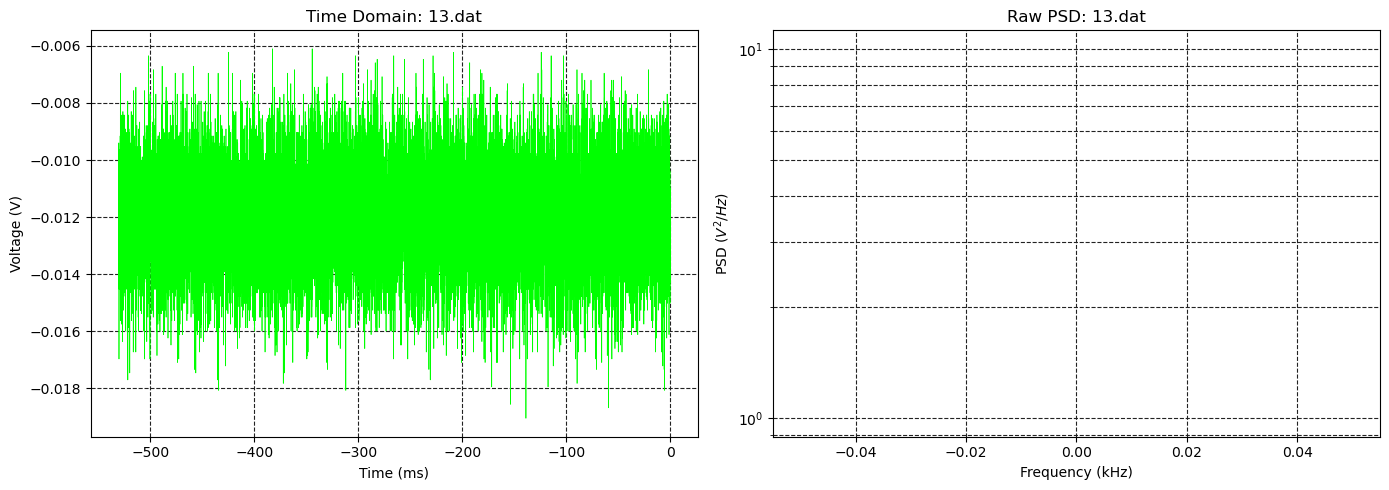

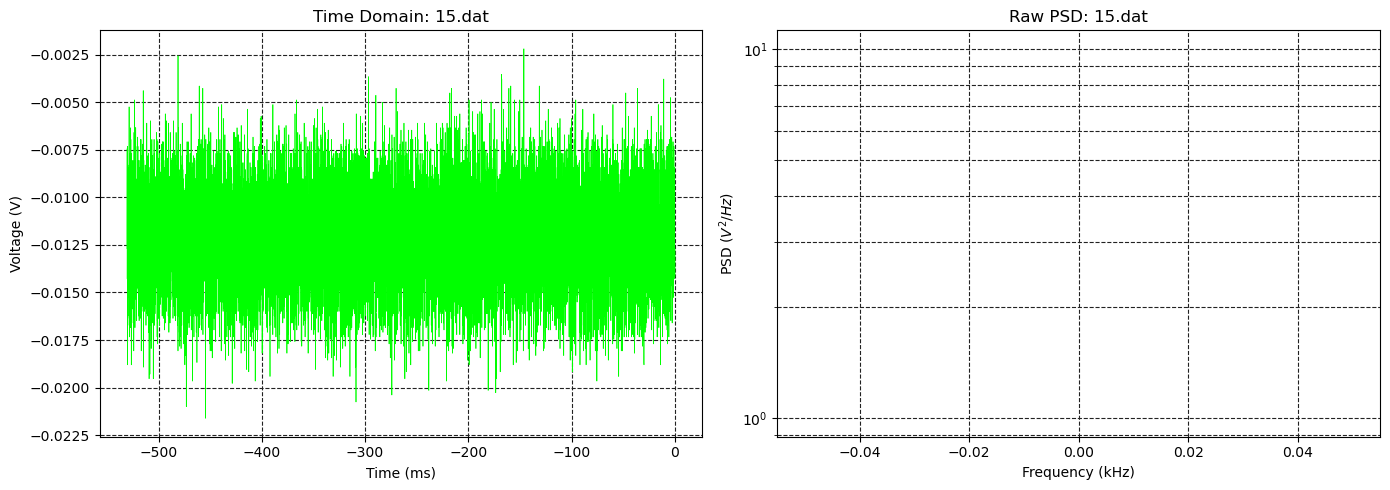

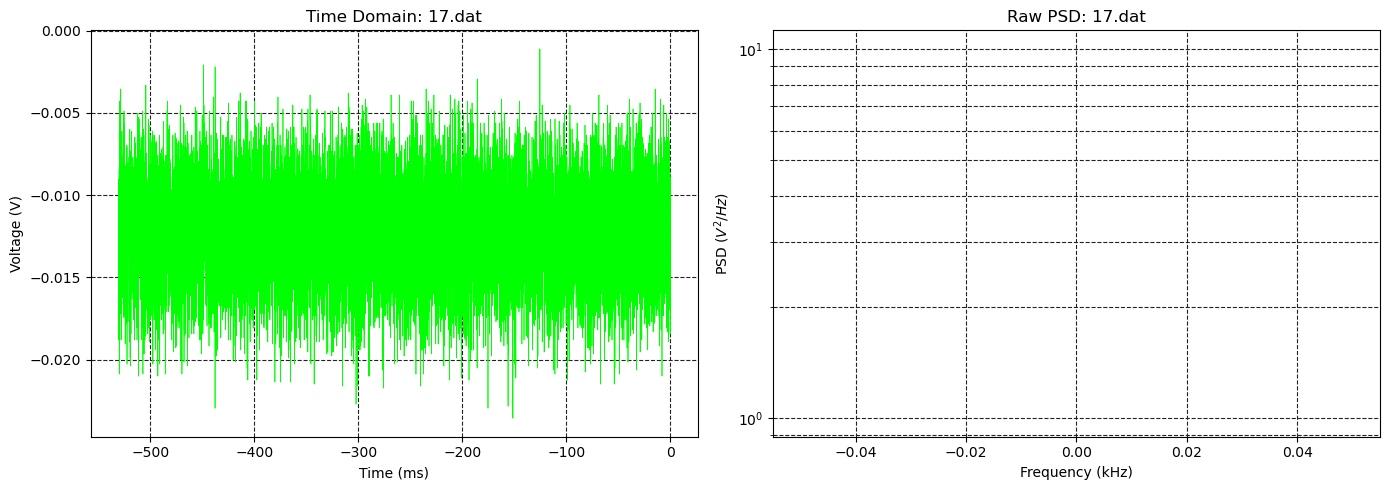

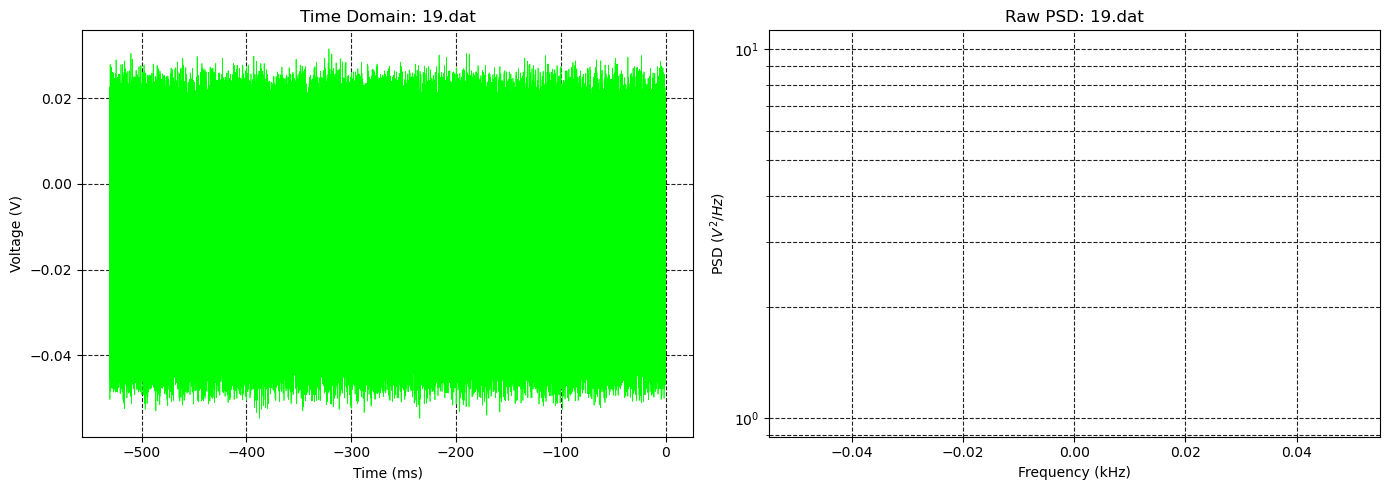

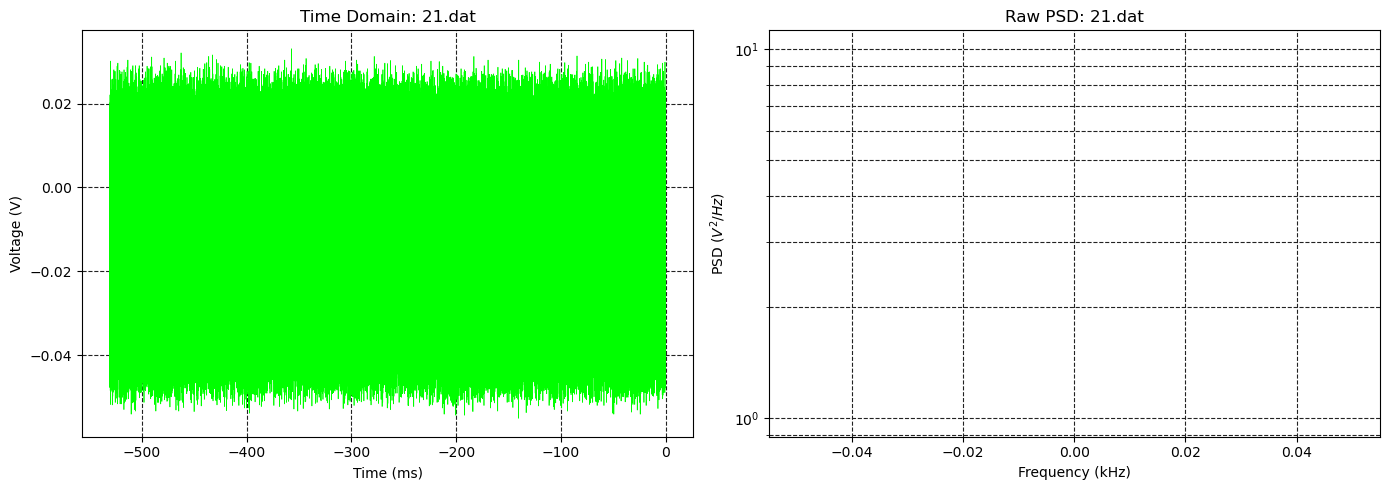

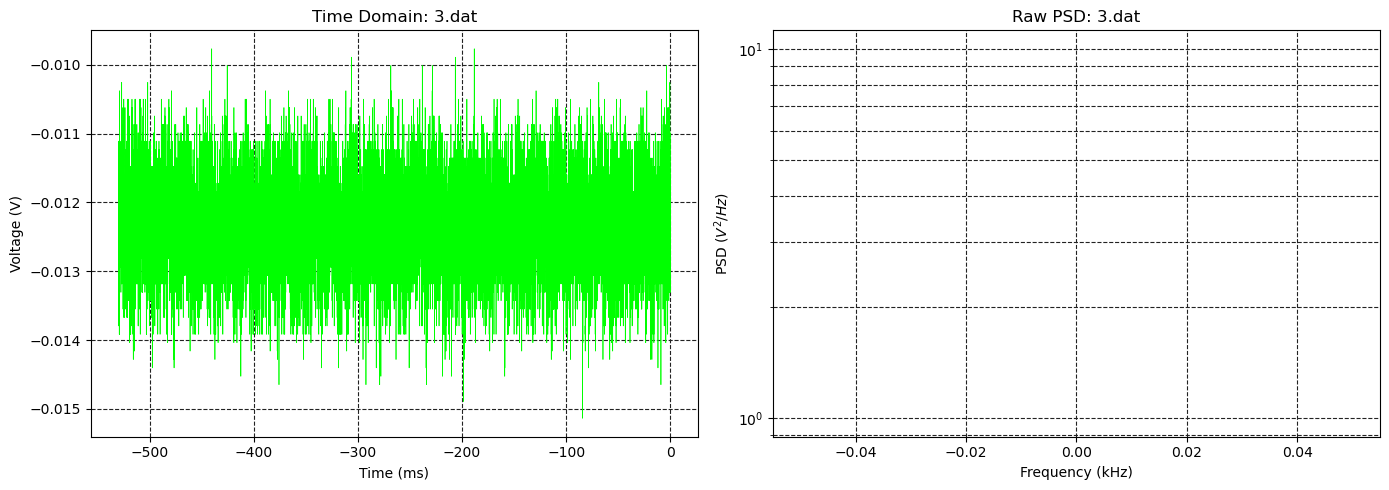

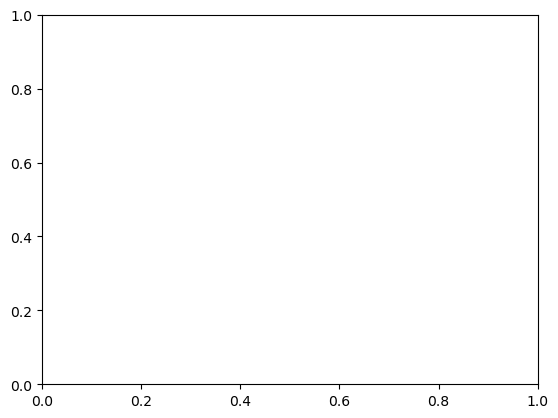

In [10]:
# run analysis for odd files
for file_idx in odd_idxs:
    mean_val, file_name, frequencies, current_psd, time_data, voltage_data, fs = calculate_file_data(file_idx, noise_psd)

    plot_file_data(mean_val, file_name, frequencies, current_psd, time_data, voltage_data)

    mean_clearances.append(mean_val)
    file_indices.append(file_name)

    color_idx += 1

In [20]:
def plot_linear(even=True):

    # Clean up Consolidated PSD plot (Image 2 Pattern)
    plt.figure(fig_all_psd.number)
    plt.semilogy(frequencies_noise / 1e3, noise_psd, color='white', linestyle='--', linewidth=1.2, label="Noise Floor (1.dat)")
    plt.xlabel("Frequency (kHz)")
    plt.ylabel("PSD ($V^2 / Hz$)")
    plt.title("Consolidated Power Spectral Density (5 Traces)", fontweight='bold')
    plt.grid(True, which='both', color='#222222', linestyle='--')
    plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))
    plt.tight_layout()

    # Clean up Average Spectral Clearance plot (Image 3 Pattern)
    plt.figure(fig_avg_clearance.number)
    plt.axhline(0, color='white', linestyle=':', alpha=0.6, label="Noise Floor (0 dB)")
    plt.xlim(0, (fs / 2) / 1e3)
    plt.xlabel("Frequency (kHz)")
    plt.ylabel("Average Clearance (dB)")
    plt.title("Clearance Level per Acquisition", fontweight='bold')
    plt.grid(True, color='#222222', linestyle='--')
    plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.0))
    plt.tight_layout()
    
    if even:
        x_data = np.array(file_indices[:11])
        y_data = np.array(mean_clearances[:11])
    else:
        x_data = np.array(file_indices[11:])
        y_data = np.array(mean_clearances[11:])

    # Compute 1st-degree polynomial fit line (y = mx + c)
    slope, intercept = np.polyfit(x_data, y_data, 1)
    x_fit = np.linspace(x_data.min() - 0.5, x_data.max() + 0.5, 100)
    y_fit = slope * x_fit + intercept

    print("\n--- Linear Regression Statistics ---")
    print(f"Calculated Fit Line Equation: Clearance = {slope:.3f} * (File Index) + ({intercept:.3f})")

    fig_linear = plt.figure(num="Clearance Linear Fitting", figsize=(8, 5))
    plt.scatter(x_data, y_data, color='#00ff00', s=100, zorder=5, label="Calculated Averages")
    plt.plot(x_fit, y_fit, color='#ff007f', linestyle='--', linewidth=2, label=f"Linear Fit (Slope: {slope:.2f} dB/file)")

    # Attach numeric labels on top of data points
    for x, y in zip(x_data, y_data):
        plt.annotate(f"{y:.2f} dB", (x, y), textcoords="offset points", xytext=(0,10), ha='center', color='white')

    plt.xlabel("File Index (Acquisition Number)")
    plt.ylabel("Mean Clearance (dB)")
    plt.title("Clearance Linearity Fitting Analysis", fontweight='bold')
    plt.xticks(x_data)
    plt.grid(True, color='#222222', linestyle='--')
    plt.legend(loc="lower right")
    plt.tight_layout()

    plt.show()

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U6'), dtype('float64')) -> None

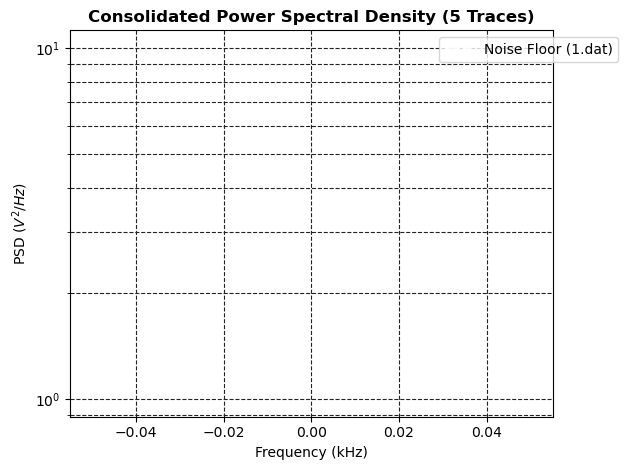

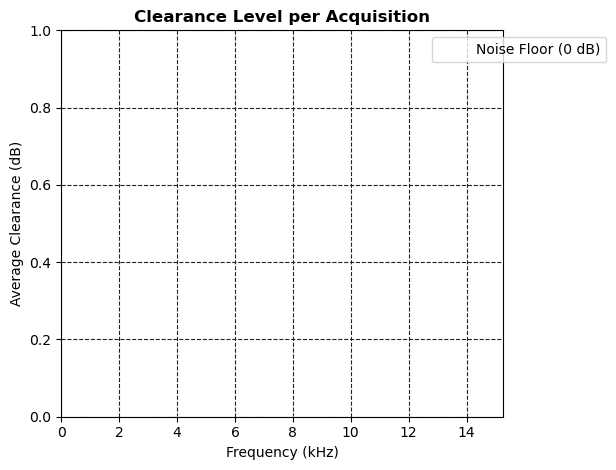

In [21]:
plot_linear(even=True)